# Churn Prediction
Tujuan: Memprediksi pelanggan yang berhenti berlangganan (churn).

## 1. Data Loading
Tujuan: Menampilkan dan melihat gambaran besar data.

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_clean.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,0,...,29.85,29.85,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,1,0,...,56.95,1889.50,0,0,0,0,0,0,0,1
2,1,0,0,0,2,1,1,1,0,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,1,1,...,42.30,1840.75,0,1,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,0,1,0,0,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   OnlineSecurity                         7032 non-null   int64  
 7   OnlineBackup                           7032 non-null   int64  
 8   DeviceProtection                       7032 non-null   int64  
 9   TechSupport                            7032 non-null   int64  
 10  StreamingTV                            7032 non-null   int64  
 11  StreamingMovies

## 2. Data Splitting
Tujuan: Memisahkan dan membagi data.

In [4]:
# Pisahkan X dan y
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 3. Scaling
Tujuan: Mengubah nilai dari berbagai fitur (variabel) dalam dataset agar memiliki rentang skala yang seragam.

In [6]:
num_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [7]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1408,1,0,1,1,1.321816,1,1,1,1,1,...,0,0.981556,1.659900,0,1,1,0,1,0,0
6992,1,0,0,0,-0.267410,0,0,0,1,1,...,0,-0.971546,-0.562252,1,0,0,0,0,1,0
3349,0,0,1,0,1.444064,1,0,1,1,1,...,0,0.837066,1.756104,0,1,1,0,1,0,0
4486,1,0,0,0,-1.204646,1,0,1,0,0,...,0,0.641092,-0.908326,0,0,1,0,0,1,0
3535,0,0,1,0,0.669826,0,1,0,0,0,...,0,-0.808787,-0.101561,1,0,0,0,0,0,0


In [8]:
X_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
971,0,0,1,1,1.105564,1,0,1,0,1,...,1,0.398769,1.046427,0,0,0,0,1,0,0
618,0,0,0,0,-1.012686,1,0,1,0,0,...,1,0.485489,-0.756277,0,1,1,0,0,0,0
4282,0,0,0,0,0.901886,1,0,0,0,0,...,0,-1.464032,-0.506686,0,0,0,1,0,0,1
3715,0,0,0,0,-1.216364,1,0,0,0,0,...,0,-1.445688,-0.973464,0,0,0,1,0,0,1
4525,0,0,1,0,1.594391,1,0,1,1,0,...,1,1.372696,2.397603,0,1,1,0,0,0,0


## 4. SMOTE
Tujuan:  membuat data baru (sintetis) dari kelas minoritas untuk mengatasi masalah ketidakseimbangan data.

In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [10]:
y_train_smote.value_counts()

Churn
0    4130
1    4130
Name: count, dtype: int64

## 5. Models
Tujuan: Mencoba dan menggunakan banyak model untuk menemukan yang terbaik.

In [ ]:
# KKN
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

# SVM
from sklearn.svm import SVC

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(X_test)


## 6. Evaluasi
Tujuan: Menemukan model terbaik.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

results = []

for name, model in models.items():

    model.fit(
        X_train_smote,
        y_train_smote
    )

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.777541,0.569794,0.665775,0.614057
3,SVM,0.749112,0.520154,0.724599,0.605587
4,Naive Bayes,0.736318,0.502703,0.745989,0.600646
0,KNN,0.717129,0.479239,0.740642,0.581933
1,Decision Tree,0.712154,0.467775,0.601604,0.526316


Model terbaiknya adalah Random Forest. Alasan Pemilihan:
- Memiliki Akurasi tertinggi (0.777541).
- Memiliki Precision tertinggi (0.569794).
- Memiliki F1-Score tertinggi (0.614057), yang membuktikan konsistensi performa terbaik dibanding model lainnya.

In [13]:
# Model terbaik
best_model = RandomForestClassifier(random_state=42)
best_model.fit(
    X_train_smote, y_train_smote
)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

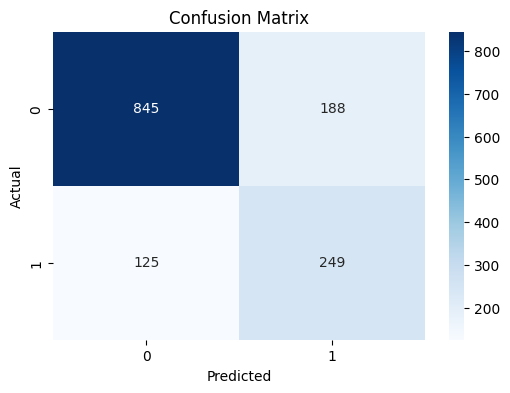

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407



Insight:
Berdasarkan hasil pengujian, model Random Forest terpilih menunjukkan performa yang solid dengan tingkat akurasi keseluruhan sebesar 78% (1.104 dari 1.407 data berhasil diprediksi dengan benar). Model ini sangat kuat dalam mengidentifikasi kelas mayoritas (Kelas 0), terbukti dari nilai precision sebesar 87% dan recall 82%, di mana model berhasil menebak 845 data secara akurat dan hanya meleset 188 data (false positive). Namun, untuk kelas minoritas (Kelas 1), model menghadapi tantangan ketidakseimbangan data (imbalance dataset) yang terlihat dari nilai support yang jauh lebih kecil (374 vs 1033), meskipun mampu menangkap 67% target aktual (249 data positif), tingkat presisinya hanya 57% karena adanya 125 kesalahan prediksi positif (false negative).